In [ ]:
import tensorflow as tf
import numpy as np
#import matplotlib.pyplot as plt
import pandas as pd
import pyfaidx
from collections import Counter, defaultdict, OrderedDict
#from modisco.visualization import viz_sequence
import logomaker
from copy import deepcopy
from tqdm import tqdm
from tqdm import tnrange
import deepdish
import pyBigWig
import tqdm
import sys
import pyfaidx
import pysam
sys.path.append("../../../chrombpnet/")
from training.utils.losses import multinomial_nll
from training.utils.one_hot import dna_to_one_hot
from evaluation.interpret.shap_utils import *
#from utils.data_utils import load_test_data, get_seq
#from training.utils.data_utils import get_seq, get_seq_cts
import matplotlib as plt
plt.rc('figure', max_open_warning = 0)
import seaborn as sns
#import hdf5plugin
import shap
import glob
tf.compat.v1.disable_eager_execution()
import matplotlib.pyplot as plt
import scipy.stats
import pandas as pd
import sklearn.cluster
from scipy.stats import chi2_contingency

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

import pyBigWig
#import anndata
import matplotlib
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import get_custom_objects
import sys
sys.path.append("../../../src/")
custom_objects={"tf":tf, "multinomial_nll":multinomial_nll}    
get_custom_objects().update(custom_objects)
from tensorflow import keras
#import proplot as pplt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage
import timeit
import statsmodels.api as sm

In [ ]:
# This function takes into account of physical overlap of the same motifs in the annotation more rigourously
def motifs_nonoverlap(motif1, motif2):
    return motif1['end'] < motif2['start'] - 3 or motif2['end'] < motif1['start'] - 3

def motifs_overlap(motif1, motif2):
    return not motifs_nonoverlap(motif1, motif2)

# Input dataframe must be sorted by start position of the motif hits
def count_co_occurrences(df):
    co_occurrences_count_per_peak = defaultdict(lambda: defaultdict(int))
    grouped_df = df.groupby('peak')

    for group_name, group_df in grouped_df:
        n = len(group_df)

        for i in range(n):
            motif1 = group_df.iloc[i]
            skipList = []
            for j in range(i + 1, n):
                motif2 = group_df.iloc[j]
                
                if (motif1.key,motif2.key) in skipList or (motif2.key,motif1.key) in skipList:
                    continue

                # Skip only this pair if different motifs overlap
                if motif1['key'] != motif2['key'] and motifs_overlap(motif1, motif2):
                    skipList.append( (motif1.key,motif2.key) )
                    skipList.append( (motif2.key,motif1.key) )
                    continue

                # Count valid co-occurrence
                mpair = tuple(sorted((motif1['key'], motif2['key'])))
                co_occurrences_count_per_peak[mpair][group_name] += 1

    # Collapse nested structure into final result
    result = defaultdict(dict)
    for motif_pair, peak_counts in co_occurrences_count_per_peak.items():
        for peak, count in peak_counts.items():
            result[motif_pair][peak] = count

    return result

In [ ]:
### This function is to calculate unfiltered
def unfiltered_count_co_occurrences(peak_hit_counts):
    """
    From an N x M (peaks by motifs) array of hit counts, returns
    an M x M array of counts (i.e. how many times two motifs occur
    together in the same peak). For the diagonal entries, we require
    that motif occur at least twice in a peak to be counted.
    """
    peak_hit_indicators = (peak_hit_counts > 0).astype(int)
    num_motifs = peak_hit_indicators.shape[1]
    count_matrix = np.zeros((num_motifs, num_motifs), dtype=int)
    for i in range(num_motifs):
        for j in range(i):
            pair_col = np.sum(peak_hit_indicators[:, [i, j]], axis=1)
            count = np.sum(pair_col == 2)
            count_matrix[i, j] = count
            count_matrix[j, i] = count
        count_matrix[i, i] = np.sum(peak_hit_counts[:, i] >= 2)
    return count_matrix

In [ ]:
lst_keys =[]
lst_values = []
with open('all_motif_clusters.annot.meme', 'r') as f:
    for l in f.readlines():
            if l.startswith("MOTIF"):
                l = l.split()[-1].split(' ')[0]
                lst_values.append(l)
                l = l.split()[-1].split('|')[0]
                lst_keys.append(l)

res = {lst_keys[i]: lst_values[i] for i in range(len(lst_keys))}

In [ ]:
def check_motif_within_peak(motif_start, motif_end, peak_start, peak_end):
    return peak_start <= motif_start <= motif_end <= peak_end

In [ ]:
#cmap1 = pplt.Colormap('Blues7_r', 'Reds', name='Diverging', save=True)
custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list( 'custom',plt.get_cmap('Reds')(np.linspace(0,1,100)**(2)) )
custom_cmap1 = matplotlib.colors.LinearSegmentedColormap.from_list( '',['white',*plt.cm.Reds((np.linspace(0,1,100)**(2)))])

In [ ]:
# Union list of neural conserved motifs
Mlig_order = ['WC_0113','WC_0823','WC_0335','JC_0216','WC_0405',
              'WC_0650','WC_0647','WC_0626','WC_0614','WC_0612',
              'JC_0280','WC_0400','WC_0014','WC_0602','WC_0572',
              'JC_0349','JC_0350','JC_0352','WC_0542','WC_0011',
              'WC_0521','JC_0397','JC_0401','WC_0514','WC_0496',
              'JC_0412','JC_0420','WC_0782','WC_0755','WC_0825',
              'WC_1093','WC_1974','WC_1973','WC_1970','WC_1969',
              'WC_1968','WC_1803','WC_1784','WC_0149','WC_0232',
              'WC_1252','WC_1159','WC_0282','WC_1485','JC_0428',
              'WC_0826','WC_0036','WC_0969','WC_0856','WC_0288',
              'WC_0485','WC_0794','WC_0781','WC_0565','WC_0529',
              'WC_1384','JC_0211','WC_0827','WC_0045','WC_0491',
              'WC_0171','JC_0392','WC_1919','WC_1367','WC_0386',
              'WC_0470','WC_0551','JC_0054','WC_0786','JC_0257',
              'WC_0098','WC_0747','WC_0018','JC_0318','WC_0618',
              'JC_0238','JC_0118','WC_1977','WC_0765','WC_0611',
              'JC_0393','WC_1013','WC_1527','WC_0607','WC_1692',
              'WC_0613','WC_1574','WC_0912','JC_0071','WC_0412',
              'WC_0054','WC_1955','WC_0383','WC_0724','WC_1240',
              'WC_0725','JC_0303','JC_0368','JC_0266','WC_0997',
              'JC_0411','JC_0217','WC_1653','WC_0074','WC_1091',
              'WC_0977','WC_0979','JC_0424','WC_0175','JC_0141',
              'JC_0272','WC_0194','WC_0589','WC_0651','JC_0192',
              'WC_1799','JC_0418','WC_0037','WC_0181','WC_0351',
              'JC_0030','JC_0117','JC_0407','JC_0275','JC_0255',
              'WC_0597','JC_0414','JC_0162','JC_0373','WC_0001',
              'WC_1174','WC_0056','WC_1010','WC_1590','WC_0648',
              'WC_1011','WC_0022','JC_0022','WC_1071','WC_0503',
              'JC_0010','WC_1374','WC_0047','WC_0193','WC_1641',
              'JC_0147','WC_0484','JC_0011','JC_0381','JC_0062',
              'JC_0263','WC_1024','JC_0223','WC_0754','WC_1496',
              'WC_0469','WC_0031','WC_0475','WC_0996','WC_0511',
              'WC_0472','JC_0165','WC_1645','JC_0012','JC_0046',
              'WC_0116','JC_0278','WC_1256','WC_0920','JC_0353',
              'JC_0396','WC_0578','JC_0099','JC_0214','WC_0334',
              'WC_0416','JC_0123','WC_1243','JC_0184','WC_0509',
              'JC_0050','WC_1309','JC_0136','WC_0524','WC_0575',
              'WC_0645','WC_0084','WC_1236','WC_0908','JC_0032',
              'WC_1573','JC_0193','WC_0486','WC_0885','JC_0072',
              'WC_1460','WC_0474','WC_0017','WC_0761','JC_0305',
              'WC_0122','WC_1528','WC_0201','JC_0028','WC_0646',
              'WC_0719','WC_0976','WC_0478','WC_0015','WC_0121',
              'WC_0410','WC_0968','JC_0031','WC_1302','JC_0150',
              'JC_0034','JC_0095','JC_0320','WC_0174','WC_0294',
              'WC_0398','JC_0283','WC_0590','WC_0677','WC_0721',
              'WC_0271','JC_0190','JC_0094','WC_0727','JC_0043',
              'JC_0197','JC_0178','JC_0256','WC_0722','JC_0014',
              'JC_0096','WC_0855','JC_0018','JC_0001','JC_0212',
              'JC_0170','JC_0297','WC_1134','JC_0073','JC_0315',
              'WC_0185','WC_1565','WC_1458','WC_1518','JC_0410',
              'JC_0078','JC_0250','WC_0948','JC_0115','WC_0993',
              'WC_0247','JC_0024','JC_0101','WC_0105','WC_0169',
              'WC_0515','JC_0047','JC_0294','JC_0106','JC_0247',
              'WC_1114','JC_0348','WC_1576','JC_0070','JC_0218',
              'JC_0058','JC_0069','JC_0131','WC_1648','WC_0324',
              'WC_1260','JC_0384','JC_0324','WC_0061','WC_1125',
              'JC_0066','WC_1033','WC_0629','WC_1176','WC_0285',
              'JC_0264','WC_0102','JC_0067','WC_0962','JC_0129',
              'JC_0331','JC_0224','JC_0306','JC_0325','WC_0928',
              'WC_1917','WC_1383','WC_0919','JC_0166','WC_1156',
              'WC_1294','WC_0107','JC_0130','WC_1796','WC_0519',
              'WC_2006','JC_0079','WC_1078','JC_0004','JC_0080',
              'WC_0423','WC_1290','JC_0389','JC_0158','WC_1253',
              'JC_0065','JC_0172','JC_0161','JC_0105','WC_0394',
              'WC_1694','WC_0975','WC_0992','WC_0966','JC_0142',
              'WC_1470','WC_1292','WC_0226','WC_0921','JC_0006',
              'JC_0182','WC_1455','WC_0632','WC_0925']

## S.mansoni

In [ ]:
neural = pd.read_csv('../../motif_filtration/schisto/neural_mean_motifs_SHAP_filtered_98.tsv',sep="\t")

neural['peak'] = neural.peak_chrom + ':' + (neural.peak_start+1).astype(str) + '-' + neural.peak_end.astype(str)
neural_final = pd.read_csv('../../motif_filtration/neural_muscle/schisto_Neural_final.csv',sep=',',index_col=0)
neural_final_sub = neural_final.sort_values(by='prob_da',ascending=False)
#neural_final_sub = neural_final_sub.head(n=6000)
neural = neural[neural.peak.isin(neural_final_sub.Peak)]
neural_sub= neural[["peak", "start","end","key"]]

In [ ]:
### Unfiltered cooccurence, what I need is an input of peakxmotif matrix 
neural_sub_table = neural_sub.groupby(['peak','key']).size().fillna(0).unstack(fill_value=0)
neural_sub_counts = neural_sub_table.to_numpy()

unfiltered_neural = unfiltered_count_co_occurrences(neural_sub_counts)
unfiltered_neural = pd.DataFrame(unfiltered_neural)
unfiltered_neural.index = neural_sub_table.columns.tolist()
unfiltered_neural.columns = neural_sub_table.columns.tolist()
unfiltered_neural.to_csv("../../Cooccurence/schisto/Figure4_Jesseneuralmotifs/schisto_Jesseneural_unfiltered_8_07_25_allmarker_union.tsv",sep="\t",index = None)

## UnFiltered_one
co_occurrences_df = pd.read_csv("../../Cooccurence/schisto/Figure4_Jesseneuralmotifs/schisto_Jesseneural_unfiltered_8_07_25_allmarker_union.tsv",sep="\t")
co_occurrences_df.index = co_occurrences_df.columns
motif_list = list(co_occurrences_df.columns)
neural_long = pd.melt(co_occurrences_df, value_vars=motif_list,value_name='Num_Peaks',ignore_index=False).reset_index()
neural_long.columns = ['motif_1','motif_2','Num_Peaks']
neural_l1 = neural_long[neural_long["motif_1"].isin(Mlig_order)]
neural_l1_l2 = neural_l1[neural_l1["motif_2"].isin(Mlig_order)]
neural_unfiltered_n = pd.pivot(neural_l1_l2, index='motif_1', columns='motif_2', values='Num_Peaks').fillna(0)

In [ ]:
# Count co-occurrences in the dataframe
start_time = timeit.default_timer()
co_occurrences_count = count_co_occurrences(neural_sub)

# Convert the result to a dataframe
co_occurrences_df = pd.DataFrame(index=neural_sub['key'].unique(), columns=neural_sub['key'].unique(), data=0)

# Update the dataframe with the co-occurrence counts
for (motif1, motif2), count in co_occurrences_count.items():
    co_occurrences_df.loc[motif1, motif2] = len(count)
    co_occurrences_df.loc[motif2, motif1] = len(count)

neural = neural_sub.groupby(['key','peak']).size()

motif_list = list(co_occurrences_df.columns)
neural_long = pd.melt(co_occurrences_df, value_vars=motif_list,value_name='Num_Peaks',ignore_index=False).reset_index()
neural_long.columns = ['motif_1','motif_2','Num_Peaks']
neural_l1 = neural_long[neural_long["motif_1"].isin(Mlig_order)]
neural_l1_l2 = neural_l1[neural_l1["motif_2"].isin(Mlig_order)]
neural_filtered_n = pd.pivot(neural_l1_l2, index='motif_1', columns='motif_2', values='Num_Peaks').fillna(0)
#neural_filtered_n.to_csv("../../Cooccurence/schisto/Figure4_Jesseneuralmotifs/schisto_rawfiltered_peakcounts_8_07_25.tsv",sep="\t")


delta = neural_unfiltered_n.sub(neural_filtered_n)

for index,row in neural_filtered_n.iterrows():
    for motif in neural_filtered_n.columns:
        motif1 = index
        #print(motif1)
        motif2 = motif
        #print(motif2)
        motif1_total = neural.loc[motif1].shape[0] - delta.loc[motif1,motif2]
        #print('motif1_total:',motif1_total)
        motif2_total = neural.loc[motif2].shape[0] - delta.loc[motif1,motif2]
        #print('motif2_total:',motif2_total)
        N = np.unique(neural_sub.peak).shape[0] # species specific peaks in filtered h5ad 
        fA = motif1_total/N
        #print('fA:',fA)
        fB = motif2_total/N
        #print('fB:',fB)
        expected = fA*fB*N
        #print('expected:', expected)
        #print('hits:',row[motif])
        if (expected < 2) and ((row[motif]) < 2):
            frac = 1
        else: 
            frac = ((row[motif])* N)/((motif1_total)*(motif2_total))
        #print('enrich:',frac)
        neural_filtered_n.at[index,motif] = frac
neural_filtered_n.to_csv("../../Cooccurence/schisto/Figure4_Jesseneuralmotifs/schisto_Jesseneural_enriched_8_07_25_allmarker_union.tsv",sep="\t")

print(timeit.default_timer() - start_time, "seconds") 

In [ ]:
## For Fisher test 
start_time = timeit.default_timer()
co_occurrences_count = count_co_occurrences(neural_sub)

# Convert the result to a dataframe
co_occurrences_df = pd.DataFrame(index=neural_sub['key'].unique(), columns=neural_sub['key'].unique(), data=0)

# Update the dataframe with the co-occurrence counts
for (motif1, motif2), count in co_occurrences_count.items():
    co_occurrences_df.loc[motif1, motif2] = len(count)
    co_occurrences_df.loc[motif2, motif1] = len(count)

neural = neural_sub.groupby(['key','peak']).size()

motif_list = list(co_occurrences_df.columns)
neural_long = pd.melt(co_occurrences_df, value_vars=motif_list,value_name='Num_Peaks',ignore_index=False).reset_index()
neural_long.columns = ['motif_1','motif_2','Num_Peaks']
neural_l1 = neural_long[neural_long["motif_1"].isin(Mlig_order)]
neural_l1_l2 = neural_l1[neural_l1["motif_2"].isin(Mlig_order)]
neural_filtered_n = pd.pivot(neural_l1_l2, index='motif_1', columns='motif_2', values='Num_Peaks').fillna(0)

delta = neural_unfiltered_n.sub(neural_filtered_n)
np.fill_diagonal(delta.values, 0)

neural_fisher_table = neural_filtered_n.copy()

for index,row in neural_filtered_n.iterrows():
    for motif in neural_filtered_n.columns:
        motif1 = index
        motif2 = motif
        N = np.unique(neural_sub.peak).shape[0]
        F_motif1_motif2 = row[motif]
        F_motif1 = neural.loc[motif1].shape[0] - delta.loc[motif1,motif2] - F_motif1_motif2
        F_motif2 = neural.loc[motif2].shape[0] - delta.loc[motif1,motif2] - F_motif1_motif2
        F_nomotif = N - F_motif1_motif2 - F_motif1 - F_motif2

        ## contigency table 
        table = np.array([[F_nomotif, F_motif1], [F_motif2, F_motif1_motif2]])
        #chi2, p_value, _, _ = chi2_contingency(table)
        pval = scipy.stats.fisher_exact(table, alternative="greater")[1]
        neural_fisher_table.at[index,motif] = pval
neural_fisher_table.to_csv("../../Cooccurence/schisto/Figure4_Jesseneuralmotifs/schisto_Jesseneural_enriched_fishertest_8_07_25_allmarker_union.tsv",sep="\t")


## S.mediterranea

In [ ]:
neural = pd.read_csv('../../motif_filtration/Smed/neural_mean_motifs_SHAP_filtered_95.tsv',sep="\t")
neural['peak'] = neural.peak_chrom + ':' + (neural.peak_start+1).astype(str) + '-' + neural.peak_end.astype(str)
neural_final = pd.read_csv('../../motif_filtration/neural_muscle/pl_Neural_final.csv',sep=',',index_col=0)
neural = neural[neural.peak.isin(neural_final.Peak)]
neural_sub= neural[["peak", "start","end","key"]]


In [ ]:
### Unfiltered cooccurence, what I need is an input of peakxmotif matrix 
neural_sub_table = neural_sub.groupby(['peak','key']).size().fillna(0).unstack(fill_value=0)
neural_sub_counts = neural_sub_table.to_numpy()

unfiltered_neural = unfiltered_count_co_occurrences(neural_sub_counts)
unfiltered_neural = pd.DataFrame(unfiltered_neural)
unfiltered_neural.index = neural_sub_table.columns.tolist()
unfiltered_neural.columns = neural_sub_table.columns.tolist()
unfiltered_neural.to_csv("../../Cooccurence/Smed/Figure4_Jesseneuralmotifs/Smed_Jesseneural_unfiltered_8_07_25_union.tsv",sep="\t",index = None)

## UnFiltered_one
co_occurrences_df = pd.read_csv("../../Cooccurence/Smed/Figure4_Jesseneuralmotifs/Smed_Jesseneural_unfiltered_8_07_25_union.tsv",sep="\t")
co_occurrences_df.index = co_occurrences_df.columns
motif_list = list(co_occurrences_df.columns)
neural_long = pd.melt(co_occurrences_df, value_vars=motif_list,value_name='Num_Peaks',ignore_index=False).reset_index()
neural_long.columns = ['motif_1','motif_2','Num_Peaks']
neural_l1 = neural_long[neural_long["motif_1"].isin(Mlig_order)]
neural_l1_l2 = neural_l1[neural_l1["motif_2"].isin(Mlig_order)]
neural_unfiltered_n = pd.pivot(neural_l1_l2, index='motif_1', columns='motif_2', values='Num_Peaks').fillna(0)

In [ ]:
# Count co-occurrences in the dataframe
start_time = timeit.default_timer()
co_occurrences_count = count_co_occurrences(neural_sub)

# Convert the result to a dataframe
co_occurrences_df = pd.DataFrame(index=neural_sub['key'].unique(), columns=neural_sub['key'].unique(), data=0)

# Update the dataframe with the co-occurrence counts
for (motif1, motif2), count in co_occurrences_count.items():
    co_occurrences_df.loc[motif1, motif2] = len(count)
    co_occurrences_df.loc[motif2, motif1] = len(count)

neural = neural_sub.groupby(['key','peak']).size()

motif_list = list(co_occurrences_df.columns)
neural_long = pd.melt(co_occurrences_df, value_vars=motif_list,value_name='Num_Peaks',ignore_index=False).reset_index()
neural_long.columns = ['motif_1','motif_2','Num_Peaks']
neural_l1 = neural_long[neural_long["motif_1"].isin(Mlig_order)]
neural_l1_l2 = neural_l1[neural_l1["motif_2"].isin(Mlig_order)]
neural_filtered_n = pd.pivot(neural_l1_l2, index='motif_1', columns='motif_2', values='Num_Peaks').fillna(0)
neural_filtered_n.to_csv("../../Cooccurence/Smed/Figure4_Jesseneuralmotifs/Smed_rawfiltered_peakcounts_8_07_25.tsv",sep="\t")

delta = neural_unfiltered_n.sub(neural_filtered_n)

for index,row in neural_filtered_n.iterrows():
    for motif in neural_filtered_n.columns:
        motif1 = index
        #print(motif1)
        motif2 = motif
        #print(motif2)
        motif1_total = neural.loc[motif1].shape[0] - delta.loc[motif1,motif2]
        #print('motif1_total:',motif1_total)
        motif2_total = neural.loc[motif2].shape[0] - delta.loc[motif1,motif2]
        #print('motif2_total:',motif2_total)
        N = np.unique(neural_sub.peak).shape[0] # species specific peaks in filtered h5ad 
        fA = motif1_total/N
        #print('fA:',fA)
        fB = motif2_total/N
        #print('fB:',fB)
        expected = fA*fB*N
        #print('expected:', expected)
        #print('hits:',row[motif])
        if (expected < 2) and ((row[motif]) < 2):
            frac = 1
        else: 
            frac = ((row[motif])* N)/((motif1_total)*(motif2_total))
        #print('enrich:',frac)
        neural_filtered_n.at[index,motif] = frac
neural_filtered_n.to_csv("../../Cooccurence/Smed/Figure4_Jesseneuralmotifs/Smed_Jesseneural_enriched_8_07_25_union.tsv",sep="\t")

print(timeit.default_timer() - start_time, "seconds") 

In [ ]:
## For Fisher test 
start_time = timeit.default_timer()
co_occurrences_count = count_co_occurrences(neural_sub)

# Convert the result to a dataframe
co_occurrences_df = pd.DataFrame(index=neural_sub['key'].unique(), columns=neural_sub['key'].unique(), data=0)

# Update the dataframe with the co-occurrence counts
for (motif1, motif2), count in co_occurrences_count.items():
    co_occurrences_df.loc[motif1, motif2] = len(count)
    co_occurrences_df.loc[motif2, motif1] = len(count)

neural = neural_sub.groupby(['key','peak']).size()

motif_list = list(co_occurrences_df.columns)
neural_long = pd.melt(co_occurrences_df, value_vars=motif_list,value_name='Num_Peaks',ignore_index=False).reset_index()
neural_long.columns = ['motif_1','motif_2','Num_Peaks']
neural_l1 = neural_long[neural_long["motif_1"].isin(Mlig_order)]
neural_l1_l2 = neural_l1[neural_l1["motif_2"].isin(Mlig_order)]
neural_filtered_n = pd.pivot(neural_l1_l2, index='motif_1', columns='motif_2', values='Num_Peaks').fillna(0)

delta = neural_unfiltered_n.sub(neural_filtered_n)
np.fill_diagonal(delta.values, 0)

neural_fisher_table = neural_filtered_n.copy()

for index,row in neural_filtered_n.iterrows():
    for motif in neural_filtered_n.columns:
        motif1 = index
        motif2 = motif
        N = np.unique(neural_sub.peak).shape[0]
        F_motif1_motif2 = row[motif]
        F_motif1 = neural.loc[motif1].shape[0] - delta.loc[motif1,motif2] - F_motif1_motif2
        F_motif2 = neural.loc[motif2].shape[0] - delta.loc[motif1,motif2] - F_motif1_motif2
        F_nomotif = N - F_motif1_motif2 - F_motif1 - F_motif2

        ## contigency table 
        table = np.array([[F_nomotif, F_motif1], [F_motif2, F_motif1_motif2]])
        #chi2, p_value, _, _ = chi2_contingency(table)
        pval = scipy.stats.fisher_exact(table, alternative="greater")[1]
        neural_fisher_table.at[index,motif] = pval
neural_fisher_table.to_csv("../../Cooccurence/Smed/Figure4_Jesseneuralmotifs/Smed_Jesseneural_enriched_fishertest_8_07_25_union.tsv",sep="\t")


## M.lignano

In [ ]:
#neural = pd.read_csv('../../motif_filtration/Mlig/self_cooccur_filtration/neural_mean_motifs_SHAP_filtered_97_self_cooccur_filtration.tsv',sep="\t")
neural = pd.read_csv('../../motif_filtration/Mlig/neural_mean_motifs_SHAP_filtered_97.tsv',sep="\t")
neural['peak'] = neural.peak_chrom + ':' + (neural.peak_start+1).astype(str) + '-' + neural.peak_end.astype(str)
neural_final = pd.read_csv('../../motif_filtration/neural_muscle/Mlig_Neural_final.csv',sep=',',index_col=0)
neural_final_sub = neural_final.sort_values(by='prob_da',ascending=False)
neural_final_sub = neural_final_sub.head(n=8000)
neural = neural[neural.peak.isin(neural_final_sub.Peak)]
neural_sub= neural[["peak", "start","end","key"]]

In [ ]:
### Unfiltered cooccurence, what I need is an input of peakxmotif matrix 
neural_sub_table = neural_sub.groupby(['peak','key']).size().fillna(0).unstack(fill_value=0)
neural_sub_counts = neural_sub_table.to_numpy()

unfiltered_neural = unfiltered_count_co_occurrences(neural_sub_counts)
unfiltered_neural = pd.DataFrame(unfiltered_neural)
unfiltered_neural.index = neural_sub_table.columns.tolist()
unfiltered_neural.columns = neural_sub_table.columns.tolist()
#unfiltered_neural.to_csv("../../Cooccurence/Mlig/Figure4_Jesseneuralmotifs/Mlig_Jesseneural_unfiltered_8_07_25_allmarker_8k_union.tsv",sep="\t",index = None)

## UnFiltered_one
co_occurrences_df = pd.read_csv("../../Cooccurence/Mlig/Figure4_Jesseneuralmotifs/Mlig_Jesseneural_unfiltered_8_07_25_allmarker_8k_union.tsv",sep="\t")
co_occurrences_df.index = co_occurrences_df.columns
motif_list = list(co_occurrences_df.columns)
neural_long = pd.melt(co_occurrences_df, value_vars=motif_list,value_name='Num_Peaks',ignore_index=False).reset_index()
neural_long.columns = ['motif_1','motif_2','Num_Peaks']
neural_l1 = neural_long[neural_long["motif_1"].isin(Mlig_order)]
neural_l1_l2 = neural_l1[neural_l1["motif_2"].isin(Mlig_order)]
neural_unfiltered_n = pd.pivot(neural_l1_l2, index='motif_1', columns='motif_2', values='Num_Peaks').fillna(0)

In [ ]:
# Count co-occurrences in the dataframe
start_time = timeit.default_timer()
co_occurrences_count = count_co_occurrences(neural_sub)

# Convert the result to a dataframe
co_occurrences_df = pd.DataFrame(index=neural_sub['key'].unique(), columns=neural_sub['key'].unique(), data=0)

# Update the dataframe with the co-occurrence counts
for (motif1, motif2), count in co_occurrences_count.items():
    co_occurrences_df.loc[motif1, motif2] = len(count)
    co_occurrences_df.loc[motif2, motif1] = len(count)

neural = neural_sub.groupby(['key','peak']).size()

motif_list = list(co_occurrences_df.columns)
neural_long = pd.melt(co_occurrences_df, value_vars=motif_list,value_name='Num_Peaks',ignore_index=False).reset_index()
neural_long.columns = ['motif_1','motif_2','Num_Peaks']
neural_l1 = neural_long[neural_long["motif_1"].isin(Mlig_order)]
neural_l1_l2 = neural_l1[neural_l1["motif_2"].isin(Mlig_order)]
neural_filtered_n = pd.pivot(neural_l1_l2, index='motif_1', columns='motif_2', values='Num_Peaks').fillna(0)
#neural_filtered_n.to_csv("../../Cooccurence/Mlig/Figure4_Jesseneuralmotifs/Mlig_rawfiltered_peakcounts_8_07_25.tsv",sep="\t")

delta = neural_unfiltered_n.sub(neural_filtered_n)

for index,row in neural_filtered_n.iterrows():
    for motif in neural_filtered_n.columns:
        motif1 = index
        #print(motif1)
        motif2 = motif
        #print(motif2)
        motif1_total = neural.loc[motif1].shape[0] - delta.loc[motif1,motif2]
        #print('motif1_total:',motif1_total)
        motif2_total = neural.loc[motif2].shape[0] - delta.loc[motif1,motif2]
        #print('motif2_total:',motif2_total)
        N = np.unique(neural_sub.peak).shape[0] # species specific peaks in filtered h5ad 
        fA = motif1_total/N
        #print('fA:',fA)
        fB = motif2_total/N
        #print('fB:',fB)
        expected = fA*fB*N
        #print('expected:', expected)
        #print('hits:',row[motif])
        if (expected < 2) and ((row[motif]) < 2):
            frac = 1
        else: 
            frac = ((row[motif])* N)/((motif1_total)*(motif2_total))
        #print('enrich:',frac)
        neural_filtered_n.at[index,motif] = frac
neural_filtered_n.to_csv("../../Cooccurence/Mlig/Figure4_Jesseneuralmotifs/Mlig_Jesseneural_enriched_8_07_25_allmarker_8k_union.tsv",sep="\t")
print(timeit.default_timer() - start_time, "seconds") 

In [ ]:
## For Fisher test 
start_time = timeit.default_timer()
co_occurrences_count = count_co_occurrences(neural_sub)

# Convert the result to a dataframe
co_occurrences_df = pd.DataFrame(index=neural_sub['key'].unique(), columns=neural_sub['key'].unique(), data=0)

# Update the dataframe with the co-occurrence counts
for (motif1, motif2), count in co_occurrences_count.items():
    co_occurrences_df.loc[motif1, motif2] = len(count)
    co_occurrences_df.loc[motif2, motif1] = len(count)

neural = neural_sub.groupby(['key','peak']).size()

motif_list = list(co_occurrences_df.columns)
neural_long = pd.melt(co_occurrences_df, value_vars=motif_list,value_name='Num_Peaks',ignore_index=False).reset_index()
neural_long.columns = ['motif_1','motif_2','Num_Peaks']
neural_l1 = neural_long[neural_long["motif_1"].isin(Mlig_order)]
neural_l1_l2 = neural_l1[neural_l1["motif_2"].isin(Mlig_order)]
neural_filtered_n = pd.pivot(neural_l1_l2, index='motif_1', columns='motif_2', values='Num_Peaks').fillna(0)

delta = neural_unfiltered_n.sub(neural_filtered_n)
np.fill_diagonal(delta.values, 0)

neural_fisher_table = neural_filtered_n.copy()

for index,row in neural_filtered_n.iterrows():
    for motif in neural_filtered_n.columns:
        motif1 = index
        motif2 = motif
        N = np.unique(neural_sub.peak).shape[0]
        F_motif1_motif2 = row[motif]
        F_motif1 = neural.loc[motif1].shape[0] - delta.loc[motif1,motif2] - F_motif1_motif2
        F_motif2 = neural.loc[motif2].shape[0] - delta.loc[motif1,motif2] - F_motif1_motif2
        F_nomotif = N - F_motif1_motif2 - F_motif1 - F_motif2

        ## contigency table 
        table = np.array([[F_nomotif, F_motif1], [F_motif2, F_motif1_motif2]])
        #chi2, p_value, _, _ = chi2_contingency(table)
        pval = scipy.stats.fisher_exact(table, alternative="greater")[1]
        neural_fisher_table.at[index,motif] = pval
neural_fisher_table.to_csv("../../Cooccurence/Mlig/Figure4_Jesseneuralmotifs/Mlig_Jesseneural_enriched_fishertest_8_07_25_allmarker_8k_union.tsv",sep="\t")


### Barplot

### Mlig

In [490]:
## Here plotting fraction of peaks to enrichment color coded by Fisher
Mlig_rawpeaks = pd.read_csv("../../Cooccurence/Mlig/Figure4_Jesseneuralmotifs/Mlig_rawfiltered_peakcounts_8_07_25.tsv",sep="\t",index_col=0)
Mlig_enrichment = pd.read_csv("../../Cooccurence/Mlig/Figure4_Jesseneuralmotifs/Mlig_Jesseneural_enriched_8_07_25_allmarker_8k_union.tsv",sep="\t",index_col=0)
Mlig_fisher = pd.read_csv("../../Cooccurence/Mlig/Figure4_Jesseneuralmotifs/Mlig_Jesseneural_enriched_fishertest_8_07_25_allmarker_8k_union.tsv",sep="\t",index_col=0)

In [491]:
# Raw peaks
Mlig_rawpeaks_motif_list = list(Mlig_rawpeaks.columns)
Mlig_rawpeaks_long = pd.melt(Mlig_rawpeaks, value_vars=Mlig_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
Mlig_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(Mlig_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Mlig_rawpeaks_long.index)
Mlig_rawpeaks_long_final = Mlig_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
Mlig_rawpeaks_long_final = Mlig_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
Mlig_enrichment_motif_list = list(Mlig_enrichment.columns)
Mlig_enrichment_long = pd.melt(Mlig_enrichment, value_vars=Mlig_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
Mlig_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(Mlig_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Mlig_enrichment_long.index)
Mlig_enrichment_long_final = Mlig_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
Mlig_enrichment_long_final = Mlig_enrichment_long_final.reset_index(drop=True)

# Fisher 
alpha = 0.1 
Mlig_fisher_motif_list = list(Mlig_fisher.columns)
Mlig_fisher_long = pd.melt(Mlig_fisher, value_vars=Mlig_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
Mlig_fisher_long[['motif_1', 'variable']] = pd.DataFrame(Mlig_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Mlig_fisher_long.index)
Mlig_fisher_long_final = Mlig_fisher_long.drop_duplicates(subset=['motif_1','variable'])
Mlig_fisher_long_final.loc[Mlig_fisher_long_final['motif_1'] == Mlig_fisher_long_final['variable'], 'Fisher'] = 1
Mlig_fisher_long_final = Mlig_fisher_long_final.reset_index(drop=True)
Mlig_fisher_counts = Mlig_fisher_long_final.Fisher.to_numpy()
_, p, _, _ = sm.stats.multipletests( Mlig_fisher_counts, alpha=alpha,method='fdr_bh' )
Mlig_fisher_long_final['multiple'] = p

In [492]:
Mlig_merged = Mlig_rawpeaks_long_final.merge(Mlig_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(Mlig_fisher_long_final, on=["motif_1", "variable"], how="outer") \

Mlig_merged['Peak'] = Mlig_merged['Peak']/8000
Mlig_filtered = Mlig_merged[Mlig_merged["motif_1"] != Mlig_merged["variable"]]


In [493]:
Mlig_filtered = pd.concat(
    [Mlig_filtered, pd.DataFrame([['JC_0012','JC_0162',1.0,1.0,1.0,1.0]], columns=Mlig_filtered.columns)],
    ignore_index=True
)

In [520]:
Mlig_filtered_powerlaw = apply_powerlaw_threshold(
    Mlig_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4.9, c=0.8,
    x_min=1.5, y_min=0.003,
    keep="above"
)

# points that pass
Mlig_filtered_passed = Mlig_filtered_powerlaw[Mlig_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(Mlig_filtered_passed)} points passed out of {len(Mlig_filtered_powerlaw)}")

445 points passed out of 54616


/tmp/ipykernel_15961/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


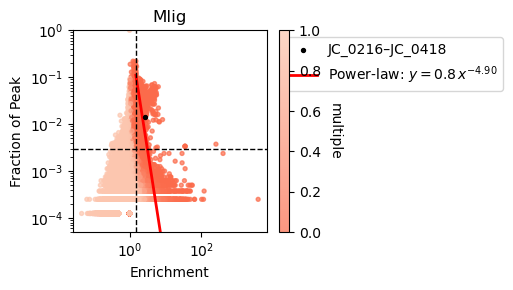

Highlighted rows: 1


In [521]:
# --- given fit parameters ---
alpha = 4.9
c = 0.8

# --- choose x-range for the curve ---
x_min, x_max = 1.5, 40     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))

# --- highlight the specific pair (order-independent) ---
a, b = "JC_0216", "JC_0418"
mask_pair = (
    ((Mlig_filtered["motif_1"] == a) & (Mlig_filtered["variable"] == b)) |
    ((Mlig_filtered["motif_1"] == b) & (Mlig_filtered["variable"] == a))
)

plt.figure(figsize=(5,3))

# ---- base scatter (everything except highlighted) ----
sc = plt.scatter(
    Mlig_filtered.loc[~mask_pair, "Enrichment"],
    Mlig_filtered.loc[~mask_pair, "Peak"],
    c=Mlig_filtered.loc[~mask_pair, "multiple"],
    cmap=cmap,
    alpha=0.7,
    s=8,
    rasterized=True
)

# ---- highlighted motif pair ----
plt.scatter(
    Mlig_filtered.loc[mask_pair, "Enrichment"],
    Mlig_filtered.loc[mask_pair, "Peak"],
    color="black",
    s=8,
    zorder=10,
    label=f"{a}–{b}",
)

# ---- colorbar ----
cbar = plt.colorbar(sc)
cbar.set_label("multiple", rotation=270, labelpad=15)

# ---- overlay curve ----
plt.plot(
    x_line, y_line, lw=2, color="red",
    label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$"
)

plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005, 1])

plt.axhline(y=0.003, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("Mlig")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
#plt.savefig("./Figures/Schisto_cooccurrence_rasterized.svg",dpi=600)
plt.show()

# optional sanity check
print("Highlighted rows:", mask_pair.sum())

### Smed

In [496]:
## Here plotting fraction of peaks to enrichment color coded by Fisher
Smed_rawpeaks = pd.read_csv("../../Cooccurence/Smed/Figure4_Jesseneuralmotifs/Smed_rawfiltered_peakcounts_8_07_25.tsv",sep="\t",index_col=0)
Smed_enrichment = pd.read_csv("../../Cooccurence/Smed/Figure4_Jesseneuralmotifs/Smed_Jesseneural_enriched_8_07_25_union.tsv",sep="\t",index_col=0)
Smed_fisher = pd.read_csv("../../Cooccurence/Smed/Figure4_Jesseneuralmotifs/Smed_Jesseneural_enriched_fishertest_8_07_25_union.tsv",sep="\t",index_col=0)

In [497]:
# Raw peaks
Smed_rawpeaks_motif_list = list(Smed_rawpeaks.columns)
Smed_rawpeaks_long = pd.melt(Smed_rawpeaks, value_vars=Smed_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
Smed_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(Smed_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Smed_rawpeaks_long.index)
Smed_rawpeaks_long_final = Smed_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
Smed_rawpeaks_long_final = Smed_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
Smed_enrichment_motif_list = list(Smed_enrichment.columns)
Smed_enrichment_long = pd.melt(Smed_enrichment, value_vars=Smed_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
Smed_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(Smed_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Smed_enrichment_long.index)
Smed_enrichment_long_final = Smed_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
Smed_enrichment_long_final = Smed_enrichment_long_final.reset_index(drop=True)

# Fisher 
alpha = 0.1 
Smed_fisher_motif_list = list(Smed_fisher.columns)
Smed_fisher_long = pd.melt(Smed_fisher, value_vars=Smed_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
Smed_fisher_long[['motif_1', 'variable']] = pd.DataFrame(Smed_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=Smed_fisher_long.index)
Smed_fisher_long_final = Smed_fisher_long.drop_duplicates(subset=['motif_1','variable'])
Smed_fisher_long_final.loc[Smed_fisher_long_final['motif_1'] == Smed_fisher_long_final['variable'], 'Fisher'] = 1
Smed_fisher_long_final = Smed_fisher_long_final.reset_index(drop=True)
Smed_fisher_counts = Smed_fisher_long_final.Fisher.to_numpy()
_, p, _, _ = sm.stats.multipletests( Smed_fisher_counts, alpha=alpha,method='fdr_bh' )
Smed_fisher_long_final['multiple'] = p

In [498]:
Smed_merged = Smed_rawpeaks_long_final.merge(Smed_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(Smed_fisher_long_final, on=["motif_1", "variable"], how="outer") \

Smed_neural_totalpeak = pd.read_csv('../../motif_filtration/neural_muscle/pl_Neural_final.csv',sep=',',index_col=0).shape[0]

Smed_merged['Peak'] = Smed_merged['Peak']/Smed_neural_totalpeak
Smed_filtered = Smed_merged[Smed_merged["motif_1"] != Smed_merged["variable"]]


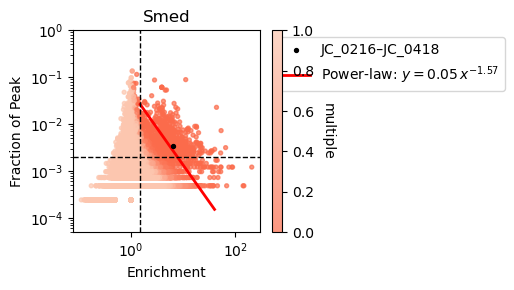

Highlighted rows: 1


In [529]:
# --- given fit parameters ---
alpha = 1.57
c = 0.05

# --- choose x-range for the curve ---
x_min, x_max = 1.5, 40     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))


# --- highlight the specific pair (order-independent) ---
a, b = "JC_0216", "JC_0418"
mask_pair = (
    ((Smed_filtered["motif_1"] == a) & (Smed_filtered["variable"] == b)) |
    ((Smed_filtered["motif_1"] == b) & (Smed_filtered["variable"] == a))
)

plt.figure(figsize=(5,3))

# ---- base scatter (everything except highlighted) ----
sc = plt.scatter(
    Smed_filtered.loc[~mask_pair, "Enrichment"],
    Smed_filtered.loc[~mask_pair, "Peak"],
    c=Smed_filtered.loc[~mask_pair, "multiple"],
    cmap=cmap,
    alpha=0.7,
    s=8,
    rasterized=True
)

# ---- highlighted motif pair ----
plt.scatter(
    Smed_filtered.loc[mask_pair, "Enrichment"],
    Smed_filtered.loc[mask_pair, "Peak"],
    color="black",
    s=8,
    zorder=10,
    label=f"{a}–{b}",
)

# ---- colorbar ----
cbar = plt.colorbar(sc)
cbar.set_label("multiple", rotation=270, labelpad=15)

# ---- overlay curve ----
plt.plot(
    x_line, y_line, lw=2, color="red",
    label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$"
)

plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005, 1])

plt.axhline(y=0.002, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("Smed")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
#plt.savefig("./Figures/Schisto_cooccurrence_rasterized.svg",dpi=600)
plt.show()

# optional sanity check
print("Highlighted rows:", mask_pair.sum())

In [528]:
Smed_filtered_powerlaw = apply_powerlaw_threshold(
    Smed_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=1.57, c=0.05,
    x_min=1.5, y_min=0.002,
    keep="above"
)

# points that pass
Smed_filtered_passed = Smed_filtered_powerlaw[Smed_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(Smed_filtered_passed)} points passed out of {len(Smed_filtered_powerlaw)}")

381 points passed out of 54285


/tmp/ipykernel_15961/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


### Schisto

In [503]:
## Here plotting fraction of peaks to enrichment color coded by Fisher
schisto_rawpeaks = pd.read_csv("../../Cooccurence/schisto/Figure4_Jesseneuralmotifs/schisto_rawfiltered_peakcounts_8_07_25.tsv",sep="\t",index_col=0)
schisto_enrichment = pd.read_csv("../../Cooccurence/schisto/Figure4_Jesseneuralmotifs/schisto_Jesseneural_enriched_8_07_25_allmarker_union.tsv",sep="\t",index_col=0)
schisto_fisher = pd.read_csv("../../Cooccurence/schisto/Figure4_Jesseneuralmotifs/schisto_Jesseneural_enriched_fishertest_8_07_25_allmarker_union.tsv",sep="\t",index_col=0)

In [504]:
# Raw peaks
schisto_rawpeaks_motif_list = list(schisto_rawpeaks.columns)
schisto_rawpeaks_long = pd.melt(schisto_rawpeaks, value_vars=schisto_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
schisto_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(schisto_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=schisto_rawpeaks_long.index)
schisto_rawpeaks_long_final = schisto_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
schisto_rawpeaks_long_final = schisto_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
schisto_enrichment_motif_list = list(schisto_enrichment.columns)
schisto_enrichment_long = pd.melt(schisto_enrichment, value_vars=schisto_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
schisto_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(schisto_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=schisto_enrichment_long.index)
schisto_enrichment_long_final = schisto_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
schisto_enrichment_long_final = schisto_enrichment_long_final.reset_index(drop=True)

# Fisher 
alpha = 0.1 
schisto_fisher_motif_list = list(schisto_fisher.columns)
schisto_fisher_long = pd.melt(schisto_fisher, value_vars=schisto_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
schisto_fisher_long[['motif_1', 'variable']] = pd.DataFrame(schisto_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=schisto_fisher_long.index)
schisto_fisher_long_final = schisto_fisher_long.drop_duplicates(subset=['motif_1','variable'])
schisto_fisher_long_final.loc[schisto_fisher_long_final['motif_1'] == schisto_fisher_long_final['variable'], 'Fisher'] = 1
schisto_fisher_long_final = schisto_fisher_long_final.reset_index(drop=True)
schisto_fisher_counts = schisto_fisher_long_final.Fisher.to_numpy()
_, p, _, _ = sm.stats.multipletests( schisto_fisher_counts, alpha=alpha,method='fdr_bh' )
schisto_fisher_long_final['multiple'] = p


In [505]:
schisto_merged = schisto_rawpeaks_long_final.merge(schisto_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(schisto_fisher_long_final, on=["motif_1", "variable"], how="outer") \

neural_totalpeak = pd.read_csv('../../motif_filtration/neural_muscle/schisto_Neural_final.csv',sep=',',index_col=0).shape[0]

schisto_merged['Peak'] = schisto_merged['Peak']/neural_totalpeak
schisto_filtered = schisto_merged[schisto_merged["motif_1"] != schisto_merged["variable"]]


In [506]:
def apply_powerlaw_threshold(df, xcol="Enrichment", ycol="Peak",
                             alpha=3.1, c=0.4,
                             x_min=1.5, y_min=0.003,
                             keep="above"):
    """
    Compare each point in df against power-law cutoff y = c * x^(-alpha).
    Also enforces x >= x_min and y >= y_min if provided.

    keep="above" returns points above the cutoff,
    keep="below" returns points below the cutoff.
    """

    x = df[xcol].to_numpy()
    y = df[ycol].to_numpy()

    # power-law cutoff line evaluated at each x
    y_cut = c * (x ** (-alpha))

    # enforce thresholds
    valid = (x >= x_min) & (y >= y_min)

    if keep == "above":
        mask = valid & (y > y_cut)
    else:
        mask = valid & (y < y_cut)

    df_out = df.copy()
    df_out["y_cutoff"] = y_cut
    df_out["pass_powerlaw"] = mask
    return df_out

In [507]:
from matplotlib.colors import LinearSegmentedColormap

custom_red = LinearSegmentedColormap.from_list(
    "custom_red",
    ["#fb6b4b", "#fcc6af"], N=1000
)
cmap=custom_red

In [508]:
schisto_filtered_powerlaw = apply_powerlaw_threshold(
    schisto_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=3.1, c=0.4,
    x_min=1.5, y_min=0.003,
    keep="above"
)

# points that pass
schisto_filtered_passed = schisto_filtered_powerlaw[schisto_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(schisto_filtered_passed)} points passed out of {len(schisto_filtered_powerlaw)}")


390 points passed out of 55611


/tmp/ipykernel_15961/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


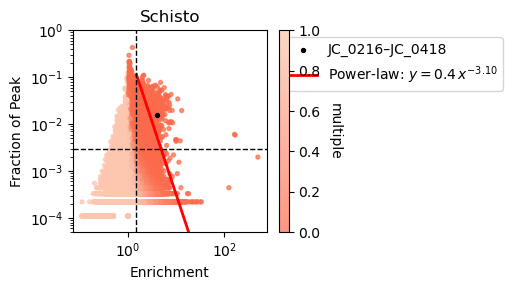

Highlighted rows: 1


In [509]:
# --- given fit parameters ---
alpha = 3.1
c = 0.4

# --- choose x-range for the curve ---
x_min, x_max = 1.5, 40     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))


# --- highlight the specific pair (order-independent) ---
a, b = "JC_0216", "JC_0418"
mask_pair = (
    ((schisto_filtered["motif_1"] == a) & (schisto_filtered["variable"] == b)) |
    ((schisto_filtered["motif_1"] == b) & (schisto_filtered["variable"] == a))
)

plt.figure(figsize=(5,3))

# ---- base scatter (everything except highlighted) ----
sc = plt.scatter(
    schisto_filtered.loc[~mask_pair, "Enrichment"],
    schisto_filtered.loc[~mask_pair, "Peak"],
    c=schisto_filtered.loc[~mask_pair, "multiple"],
    cmap=cmap,
    alpha=0.7,
    s=8,
    rasterized=True
)

# ---- highlighted motif pair ----
plt.scatter(
    schisto_filtered.loc[mask_pair, "Enrichment"],
    schisto_filtered.loc[mask_pair, "Peak"],
    color="black",
    s=8,
    zorder=10,
    label=f"{a}–{b}",
)

# ---- colorbar ----
cbar = plt.colorbar(sc)
cbar.set_label("multiple", rotation=270, labelpad=15)

# ---- overlay curve ----
plt.plot(
    x_line, y_line, lw=2, color="red",
    label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$"
)

plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005, 1])

plt.axhline(y=0.003, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("Schisto")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
#plt.savefig("./Figures/Schisto_cooccurrence_rasterized.svg",dpi=600)
plt.show()

# optional sanity check
print("Highlighted rows:", mask_pair.sum())

In [510]:
def canonicalize_pairs(df, col1="motif_1", col2="variable"):
    df = df.copy()
    # Make pair_key order-invariant
    df["pair_key"] = df.apply(
        lambda x: "&".join(sorted([x[col1], x[col2]])),
        axis=1
    )
    # Drop redundant flipped pairs (A–B vs B–A)
    df = df.drop_duplicates(subset="pair_key", keep="first")

    # (Optional) sanity check: ensure uniqueness
    assert df["pair_key"].is_unique, "pair_key still not unique!"

    return df

In [530]:
schisto_filtered_passed = canonicalize_pairs(schisto_filtered_passed)
Mlig_filtered_passed = canonicalize_pairs(Mlig_filtered_passed)
Smed_filtered_passed = canonicalize_pairs(Smed_filtered_passed)

In [531]:
common_Mlig_Smed = Mlig_filtered_passed.merge(Smed_filtered_passed, on="pair_key", suffixes=("_Mlig", "_Smed"))
common_Mlig_schisto = Mlig_filtered_passed.merge(schisto_filtered_passed, on="pair_key", suffixes=("_Mlig", "_schisto"))
common_Smed_schisto = Smed_filtered_passed.merge(schisto_filtered_passed, on="pair_key", suffixes=("_Smed", "_schisto"))


In [532]:
len(common_Mlig_Smed)

44

In [533]:
len(common_Mlig_schisto)

117

In [534]:
len(common_Smed_schisto)

197

In [535]:
# 1. Get the set of pair_keys present in all three
common_keys_all3 = (
    set(Mlig_filtered_passed["pair_key"])
    & set(Smed_filtered_passed["pair_key"])
    & set(schisto_filtered_passed["pair_key"])
)

# Optional: check how many
print("Number of motif pairs shared by all three:", len(common_keys_all3))

Number of motif pairs shared by all three: 43


/tmp/ipykernel_15961/2375098248.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Value', data=df, ax=ax, palette='viridis')


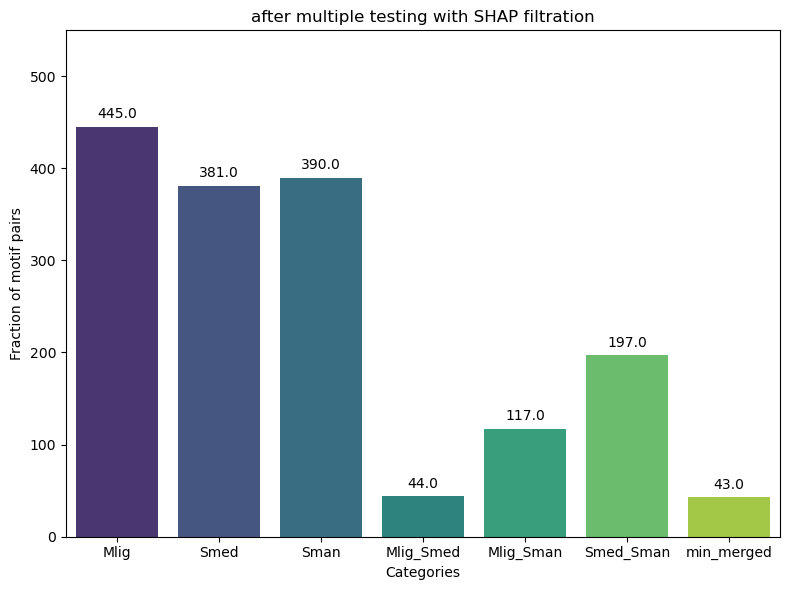

In [538]:

data = {
    'Category': ['Mlig', 'Smed', 'Sman', 'Mlig_Smed','Mlig_Sman', 'Smed_Sman', 'min_merged'],
    'Value': [len(Mlig_filtered_passed), len(Smed_filtered_passed), len(schisto_filtered_passed),
                  len(common_Mlig_Smed), len(common_Mlig_schisto), len(common_Smed_schisto), len(common_keys_all3)]
}
df = pd.DataFrame(data)

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create bar plot using Seaborn
sns.barplot(x='Category', y='Value', data=df, ax=ax, palette='viridis')

# Add data labels
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

# Add titles and labels
ax.set_xlabel('Categories')
ax.set_ylabel('Fraction of motif pairs')
ax.set_title('after multiple testing with SHAP filtration')

# Show plot
plt.tight_layout()
plt.ylim([0,550])
plt.savefig("../../Cooccurence/Figures/allneuralmotifs_powerlaw_threshold.svg")
plt.show()